#**PACE Stages**

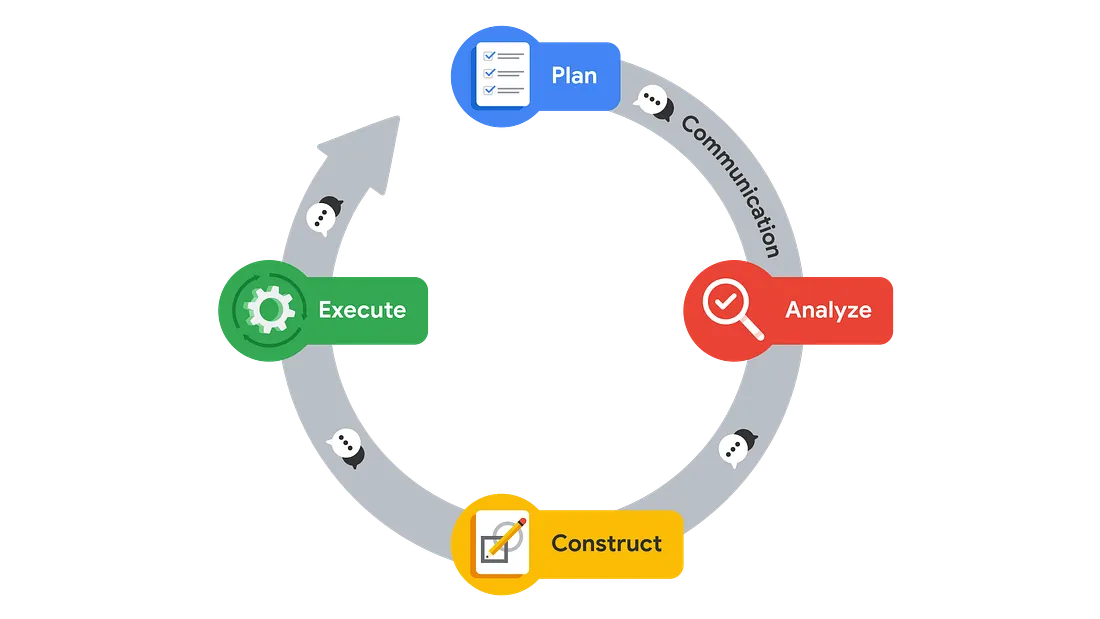

# **Pace : Plan Stage**

## 1. **Understand the Business Senario and the Problem**

**A single machine failure can cost a factory millions (the provider did not tell much)**.

## 2. **identify Stakholders**

**Primary** : The Owner of the Factory

**Secondary** : Operation Manager (might affect on the optimiztiom process and.....ete) customer support (who handle complaints related to latency of the product), and finance (who track lost revenue from fixing machine)

**Indirected affected**: consumer that permenant depending on the product

## 3. **Define the Project Scope and Goals**
**The Goal** : is not just "accuracy," but preventing expensive false alarms that halt production unnecessarily.

**Deliverables** : Build a classifier Model to predict machine failure types (e.g., Tool Wear, Overheating)
based on sensor readings (Air temperature, Process temperature, Torque).

**Bounderis** : The evaluation must focus on the False Discovery Rate. it must tune your model to minimize false positives, even if it slightly lowers  overall accuracy.

## 4. Assess what's needed

**Data**: UDI ,Product ID	,Type ,	Air temperature [K]	, Process temperature [K]	Rotational speed [rpm],	Torque [Nm],	Tool wear [min]	, Machine failure ,	TWF	HDF,	PWF,	OSF,	RNF (Some problems needs multiple sourse to extract from it)

**Tools**: Python (pandas,sklearn,scipy,statsmodels,matplotlib/seaborn) in a Jupyter notebook

**Skills**: EDA, classification modeling, feature engineering


In [1]:
import numpy as np
import pandas as pd

# Data Collection/ Fethshing

In [2]:
# Fetching the data
df = pd.read_csv("/content/ai4i_predictive_maintenance.csv")

# Data Exploration (initial Exploration)

In [3]:
# seeing Random sample of data (25 rows)
df.sample(25)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9392,9393,L97738,L,301.7,311.0,1460,33.8,101,0,0,0,0,0,0
5903,5904,L76704,L,300.8,309.5,1537,55.4,110,0,0,0,0,0,0
4711,4712,L15364,L,297.9,308.0,1639,48.9,23,0,0,0,0,0,0
3556,3557,L43053,L,304.2,314.0,1541,36.9,162,0,0,0,0,0,0
4031,4032,L52351,L,302.8,312.1,1836,43.9,169,0,0,0,0,0,0
6712,6713,M64056,M,299.0,308.6,1615,36.0,110,0,0,0,0,0,0
2534,2535,M83398,M,303.5,314.0,1663,16.0,186,0,0,0,0,0,0
9088,9089,L25565,L,301.5,310.6,1279,35.3,116,0,0,0,0,0,0
1961,1962,L16589,L,301.3,313.2,1603,14.9,142,0,0,0,0,0,0
1820,1821,L77501,L,298.5,309.0,1601,34.6,50,0,0,0,0,0,0


In [4]:
# defining the dimention of our data
df.shape

(10000, 14)

In [5]:
# Showing summary satistics and probablitiy
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.01753,2.009803,292.3,298.60,300.0,301.40,309.0
Process temperature [K],10000.0,310.01122,2.263866,301.1,308.50,310.0,311.60,320.5
Rotational speed [rpm],10000.0,1537.44100,179.389422,887.0,1414.00,1538.0,1659.00,2171.0
Torque [Nm],10000.0,39.90965,9.926393,2.9,33.30,40.0,46.60,77.2
Tool wear [min],10000.0,124.08020,72.063675,0.0,62.00,124.0,186.00,249.0
Machine failure,10000.0,0.06380,0.244409,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.01540,0.123144,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01580,0.124707,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00220,0.046855,0.0,0.00,0.0,0.00,1.0


In [6]:
# showing summarization for categorcal feature
df.describe(include='object')

,Product ID,Type
count,10000,10000
unique,9737,3
top,L46126,L
freq,3,6108


In [7]:
# information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)